# Part 1: Pruning 개념 및 Baseline 학습

## 이 노트북에서 다루는 내용
1. Pruning의 핵심 개념
2. CIFAR-10 데이터셋 로드
3. CNN 모델 학습 (Baseline)
4. 가중치 분포 시각화
5. 레이어별 파라미터 분석

---

## Pruning 핵심 아이디어

- 학습된 모델에서 **중요도가 낮은 가중치/뉴런/필터를 제거**
- **"Lottery Ticket Hypothesis"** (Frankle & Carlin, 2019): 큰 네트워크 안에 성능을 유지하는 작은 서브네트워크가 존재
- 핵심 가정: **모든 파라미터가 동일하게 중요하지 않다**

### Pruning 분류

```
Pruning
├── Unstructured (비정형)
│   └── 개별 가중치(weight) 단위로 제거
│       → 높은 압축률, 하지만 실제 속도 향상 제한적
│
└── Structured (정형)
    └── 필터/채널/레이어 단위로 제거
        → 실제 연산량 감소 및 속도 향상
```

### 중요도 기준
- **Magnitude-based**: |w| 크기 기반 (가장 일반적)
- **Gradient-based**: gradient 크기 기반
- **Taylor expansion**: 가중치 제거 시 loss 변화량 추정

## 1. 환경 설정 및 라이브러리 Import

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 모듈에서 모델 import
from module.models import CNN

In [2]:
def get_device() -> str:
    """사용 가능한 가속기 확인"""
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


DEVICE = get_device()
print(f"Using device: {DEVICE}")

# 하이퍼파라미터
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 10

# 재현성을 위한 시드 설정
SEED = 42
torch.manual_seed(SEED)

Using device: cuda


## 2. 데이터 로드 및 전처리

### CIFAR-10 데이터셋
- 10개 클래스 (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)
- 32x32 RGB 이미지
- 학습: 50,000장, 테스트: 10,000장

In [3]:
def get_data_loaders(batch_size: int = 128) -> tuple[DataLoader, DataLoader]:
    """CIFAR-10 데이터셋 로드"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])

    train_dataset = datasets.CIFAR10(
        root='./data/datasets',
        train=True,
        download=True,
        transform=transform
    )

    test_dataset = datasets.CIFAR10(
        root='./data/datasets',
        train=False,
        download=True,
        transform=transform
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True if DEVICE == "cuda" else False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True if DEVICE == "cuda" else False
    )

    return train_loader, test_loader

In [4]:
print("[1] CIFAR-10 데이터셋 로드 중...")
train_loader, test_loader = get_data_loaders(BATCH_SIZE)
print(f"    - 학습 데이터: {len(train_loader.dataset):,} 샘플")
print(f"    - 테스트 데이터: {len(test_loader.dataset):,} 샘플")

[1] CIFAR-10 데이터셋 로드 중...


100%|██████████| 170M/170M [00:18<00:00, 9.13MB/s] 


    - 학습 데이터: 50,000 샘플
    - 테스트 데이터: 10,000 샘플


## 3. 학습 및 평가 함수 정의

In [5]:
def train(
    model: nn.Module,
    train_loader: DataLoader,
    epochs: int,
    learning_rate: float,
    device: str
) -> list[float]:
    """
    일반적인 Cross-Entropy 학습

    Returns:
        각 에포크의 평균 loss 리스트
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.to(device)
    model.train()

    epoch_losses = []

    for epoch in range(epochs):
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")

    return epoch_losses

In [6]:
def test(model: nn.Module, test_loader: DataLoader, device: str) -> float:
    """모델 평가"""
    model.to(device)
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    return accuracy


def count_parameters(model: nn.Module) -> int:
    """모델의 총 파라미터 수 계산"""
    return sum(p.numel() for p in model.parameters())

## 4. CNN 모델 학습 (Baseline)

Distillation의 DeepNN과 동일한 구조를 사용합니다 (~1.18M parameters).

구조:
- 4개의 Convolutional layers (128 → 64 → 64 → 32 filters)
- 2개의 MaxPooling layers
- Fully connected classifier (2048 → 512 → 10)

이 모델을 학습한 후 다양한 Pruning 기법을 적용합니다.

In [7]:
print("[2] CNN 모델 학습 (Baseline)")
print("-" * 40)

torch.manual_seed(SEED)
model = CNN(num_classes=NUM_CLASSES).to(DEVICE)
print(f"    파라미터 수: {count_parameters(model):,}")

[2] CNN 모델 학습 (Baseline)
----------------------------------------
    파라미터 수: 1,186,986


In [8]:
# Baseline 학습
train_losses = train(model, train_loader, EPOCHS, LEARNING_RATE, DEVICE)

Epoch 1/10, Loss: 1.3422
Epoch 2/10, Loss: 0.8709
Epoch 3/10, Loss: 0.6855
Epoch 4/10, Loss: 0.5462
Epoch 5/10, Loss: 0.4350
Epoch 6/10, Loss: 0.3331
Epoch 7/10, Loss: 0.2431
Epoch 8/10, Loss: 0.1872
Epoch 9/10, Loss: 0.1485
Epoch 10/10, Loss: 0.1347


In [9]:
# Baseline 평가
baseline_accuracy = test(model, test_loader, DEVICE)

Test Accuracy: 75.01%


In [10]:
# Baseline 모델 저장
torch.save(model.state_dict(), './data/trained_models/baseline_model.pth')
print("Baseline 모델 저장: ./data/trained_models/baseline_model.pth")

Baseline 모델 저장: ./data/trained_models/baseline_model.pth


## 5. 레이어별 파라미터 분석

Pruning 전에 각 레이어가 얼마나 많은 파라미터를 가지고 있는지 확인합니다.
- Conv 레이어: 필터 수 × 입력 채널 × 커널 높이 × 커널 너비
- Linear 레이어: 입력 크기 × 출력 크기

In [11]:
print("[3] 레이어별 파라미터 분석")
print(f"{'Layer':<30} {'Shape':<25} {'Parameters':<15} {'비율':<10}")
print("-" * 80)

total_params = 0
layer_info = []

for name, param in model.named_parameters():
    num_params = param.numel()
    total_params += num_params
    layer_info.append((name, list(param.shape), num_params))

for name, shape, num_params in layer_info:
    ratio = num_params / total_params * 100
    print(f"{name:<30} {str(shape):<25} {num_params:>12,} {ratio:>8.1f}%")

print("-" * 80)
print(f"{'Total':<30} {'':<25} {total_params:>12,} {'100.0%':>10}")

[3] 레이어별 파라미터 분석
Layer                          Shape                     Parameters      비율        
--------------------------------------------------------------------------------
features.0.weight              [128, 3, 3, 3]                   3,456      0.3%
features.0.bias                [128]                              128      0.0%
features.2.weight              [64, 128, 3, 3]                 73,728      6.2%
features.2.bias                [64]                                64      0.0%
features.5.weight              [64, 64, 3, 3]                  36,864      3.1%
features.5.bias                [64]                                64      0.0%
features.7.weight              [32, 64, 3, 3]                  18,432      1.6%
features.7.bias                [32]                                32      0.0%
classifier.0.weight            [512, 2048]                  1,048,576     88.3%
classifier.0.bias              [512]                              512      0.0%
classifier.3.weigh

## 6. 가중치 분포 시각화

Pruning 전 가중치 분포를 확인합니다.
- **0 근처의 가중치가 많다** = pruning에 적합 (작은 가중치 제거 가능)
- **분포가 넓다** = 중요한 가중치와 불필요한 가중치 구분 가능
- 빨간 점선은 0을 표시합니다.

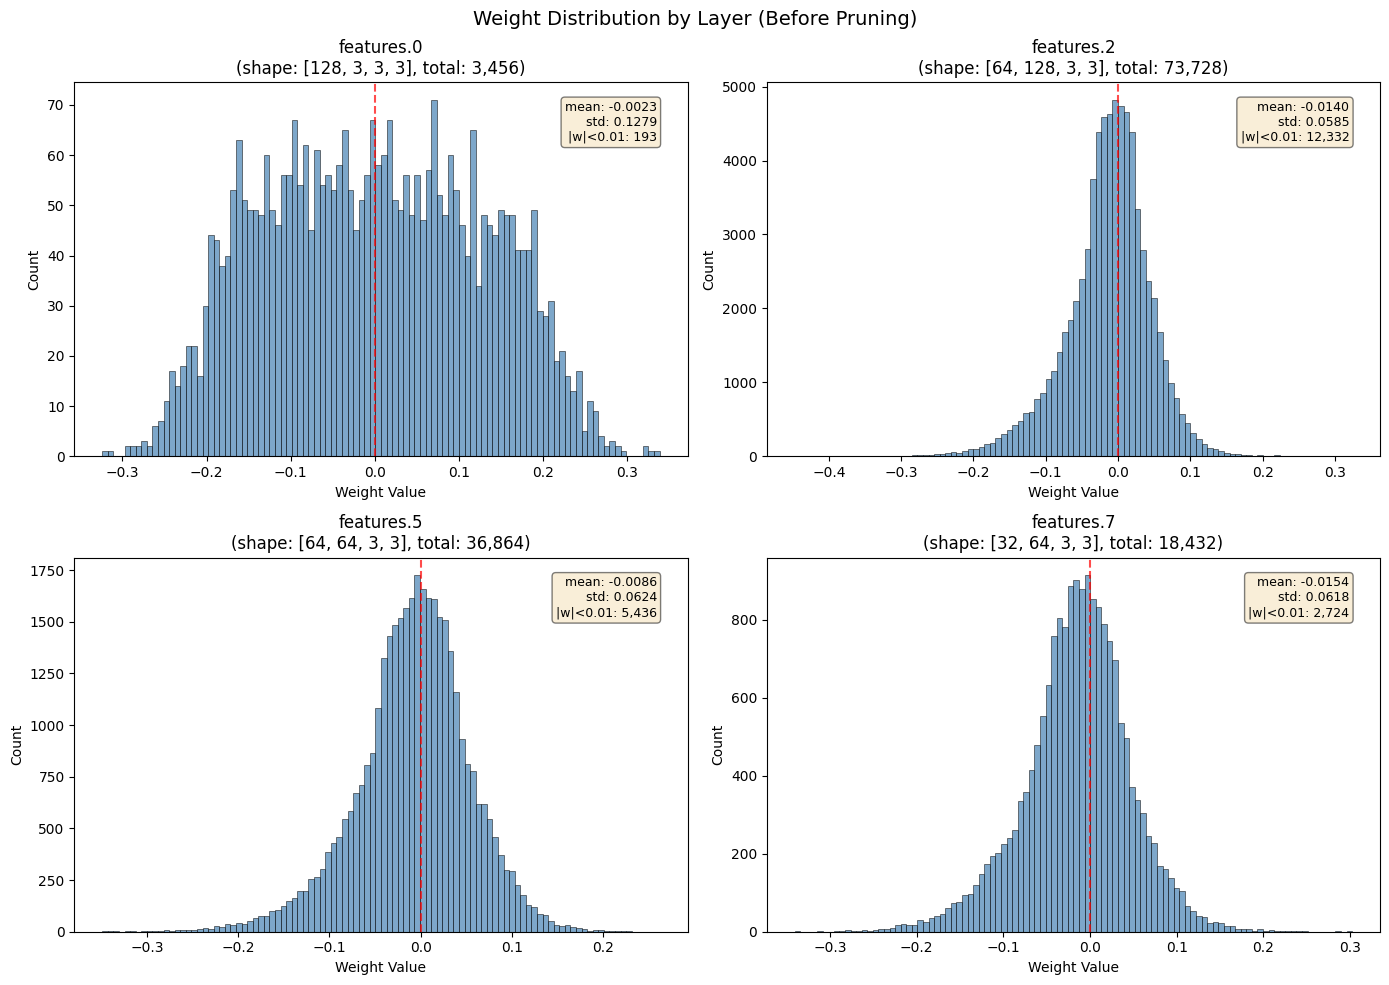

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Weight Distribution by Layer (Before Pruning)', fontsize=14)

conv_layers = []
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        conv_layers.append((name, module))

for idx, (name, layer) in enumerate(conv_layers):
    ax = axes[idx // 2][idx % 2]
    weights = layer.weight.data.cpu().numpy().flatten()

    ax.hist(weights, bins=100, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    ax.set_title(f'{name}\n(shape: {list(layer.weight.shape)}, total: {weights.size:,})')
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Count')

    # 통계 정보 표시
    stats_text = f'mean: {weights.mean():.4f}\nstd: {weights.std():.4f}\n|w|<0.01: {(np.abs(weights) < 0.01).sum():,}'
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 7. Pruning 관련 가중치 통계

다양한 threshold에서 제거 가능한 가중치 비율을 확인합니다.
- `|w| < threshold`인 가중치 = pruning 대상
- threshold가 클수록 더 많은 가중치가 제거됨

In [13]:
print("[4] Pruning 관련 가중치 통계")
print("-" * 40)

total_weights = 0
thresholds = [0.001, 0.01, 0.05, 0.1]

for name, param in model.named_parameters():
    if 'weight' in name:
        total_weights += param.numel()

print(f"총 가중치 수: {total_weights:,}")
print(f"\nThreshold별 제거 가능한 가중치 비율:")

for threshold in thresholds:
    count = 0
    for name, param in model.named_parameters():
        if 'weight' in name:
            count += (param.data.abs().cpu() < threshold).sum().item()
    print(f"    |w| < {threshold}: {count:,} ({count/total_weights*100:.1f}%)")

[4] Pruning 관련 가중치 통계
----------------------------------------
총 가중치 수: 1,186,176

Threshold별 제거 가능한 가중치 비율:
    |w| < 0.001: 28,479 (2.4%)
    |w| < 0.01: 284,185 (24.0%)
    |w| < 0.05: 872,141 (73.5%)
    |w| < 0.1: 1,087,567 (91.7%)


## 8. 결과 요약

In [14]:
print("=" * 60)
print("결과 요약")
print("=" * 60)
print(f"    모델: CNN ({count_parameters(model):,} parameters)")
print(f"    Baseline 정확도: {baseline_accuracy:.2f}%")
print(f"\n    이 모델에 다양한 Pruning 기법을 적용하여")
print(f"    정확도를 최대한 유지하면서 모델을 압축하는 것이 목표입니다!")

결과 요약
    모델: CNN (1,186,986 parameters)
    Baseline 정확도: 75.01%

    이 모델에 다양한 Pruning 기법을 적용하여
    정확도를 최대한 유지하면서 모델을 압축하는 것이 목표입니다!


In [15]:
results = {
    'baseline_accuracy': baseline_accuracy,
    'train_losses': train_losses,
    'total_params': count_parameters(model)
}

print("결과가 저장되었습니다.")
print("다음 노트북(02_unstructured_pruning.ipynb)에서 비정형 프루닝을 적용해봅니다.")

결과가 저장되었습니다.
다음 노트북(02_unstructured_pruning.ipynb)에서 비정형 프루닝을 적용해봅니다.


---

## 다음 단계

**02_unstructured_pruning.ipynb**에서는:
1. L1 Unstructured Pruning (magnitude 기반)
2. Random Unstructured Pruning
3. Global Unstructured Pruning
4. Sparsity별 정확도 변화 분석